# Consommation d'Energie des Bâtiments non résidentiels de Seattle

L'analyse exploratoire ainsi que le feature engineering ont été faits dans le template de notebook, nous reprenons ici le Dataset de départ que nous allons spliter avant d'appliquer l'encoding et la normalisation sur les colones sélectionnées. Nous choisisssons deux méthodes de split : la première est aléatoire, la seconde sera basée sur les catégories les plus corrélées. Nous appliquerons ensuite 3 modèles prédicitifs.

## Import des modules

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
from category_encoders import TargetEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error

## Import des données non-résidentielles filtrées dans le précédent notebook

In [17]:
# On ouvre le jeu de données des bâtiments non-résidentiels
nonresidential_building_consumption = pd.read_csv("../data/processed/building_consumption_non-residential_cleaned.csv")

In [18]:
# On vérifie qu'on arrive à lire les données 
nonresidential_building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


## Nettoyage des données

In [19]:
# Suppression des lignes où la conso est nulle
df_cleaned = nonresidential_building_consumption.dropna(subset=["SiteEnergyUse(kBtu)"])
df_cleaned = df_cleaned[df_cleaned['SiteEnergyUse(kBtu)'] != 0].reset_index(drop=True)

# Suppression du bâtiment trop grand identifié dans l'analyse exploratoire (campus)
df_cleaned = df_cleaned[df_cleaned['OSEBuildingID'] != 49967]

#Remplacement des NaN des PropertyUseGFA par des 0
cols_gfa = ['LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA']
for col in cols_gfa:
    df_cleaned[col] = df_cleaned[col].fillna(0)
    df_cleaned[col] = df_cleaned[col].fillna(0)

Nombre de lignes après nettoyage : 1656


## Feature engineering

In [20]:
# CODE FEATURE ENGINEERING

df = df_cleaned.copy()

# 1 ParkingRatio : ratio parking / surface totale
df['ParkingRatio'] = df.apply(
    lambda row: row['PropertyGFAParking'] / row['PropertyGFATotal']
    if row['PropertyGFATotal'] and pd.notnull(row['PropertyGFAParking']) else 0,
    axis=1
)

# 2 UsageComplexity : nombre d'usages différents
df['UsageComplexity'] = df['ListOfAllPropertyUseTypes'].apply(
    lambda s: len(s.split(', ')) if pd.notnull(s) else 0
)

# 3 HasNaturalGas : Gaz ou pas
df['HasNaturalGas'] = df['NaturalGas(therms)'].apply(lambda x: 1 if pd.notnull(x) and x > 0 else 0)

# 4 HasSteam : Vapeur ou pas
df['HasSteam']      = df['SteamUse(kBtu)'].apply(lambda x: 1 if pd.notnull(x) and x > 0 else 0)

# 5 HasEnergyStarScore : présence d'un score ENERGY STAR
df['HasEnergyStarScore'] = df['ENERGYSTARScore'].apply(lambda x: 1 if pd.notnull(x) else 0)

# 6 DensityPerFloor : densité d'espace par étage
df['DensityPerFloor'] = df.apply(
    lambda row: (
        row['PropertyGFABuilding(s)']
        if pd.notnull(row['PropertyGFABuilding(s)']) and row['NumberofFloors'] == 0
        else (
            row['PropertyGFABuilding(s)'] / row['NumberofFloors']
            if row['NumberofFloors'] and pd.notnull(row['PropertyGFABuilding(s)']) else None
        )
    ),
    axis=1
)

# 7 IsLargeBuilding : indicateur de grande taille (> median PropertyGFATotal)
median_gfa = df['PropertyGFATotal'].median()
df['IsLargeBuilding'] = df['PropertyGFATotal'].apply(lambda x: 1 if x > median_gfa else 0)

# 8 IsDowntown : localisation centre-ville (Neighborhood == 'DOWNTOWN')
df['IsDowntown'] = df['Neighborhood'].apply(lambda x: 1 if x == 'DOWNTOWN' else 0)

# 9 HasPool présence de "pool" ou "swimming" dans ListOfAllPropertyUseTypes
df['HasPool'] = df['ListOfAllPropertyUseTypes'].str.contains('pool|swimming', case=False, na=False).astype(int)

#10 Log de SiteEnergyUse
df['LogSiteEnergyUse'] = np.log1p(df['SiteEnergyUse(kBtu)'])

# Affichage des premières lignes pour vérification
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,ParkingRatio,UsageComplexity,HasNaturalGas,HasSteam,HasEnergyStarScore,DensityPerFloor,IsLargeBuilding,IsDowntown,HasPool,LogSiteEnergyUse
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,0.000000,1,1,1,1,7369.500000,1,1,0,15.793246
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,0.145453,3,1,0,1,8045.636364,1,1,0,15.942305
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,0.205748,1,1,1,1,18521.756098,1,1,0,18.100297
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,0.000000,1,1,1,1,6132.000000,1,1,0,15.731637
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,0.353115,3,1,0,1,6310.000000,1,1,1,16.466822


## Split des données

In [21]:
# Définition de la target

target = 'LogSiteEnergyUse'

### Split standard

Comme notre variable à prédire (la consommation d’énergie) est continue, nous ne pouvons pas utiliser la stratification classique.
Pour nous assurer que toutes les valeurs (petites, moyennes, grandes consommations) sont bien représentées à la fois dans l’entraînement et le test, nous découpons la cible en tranches (quantiles), de sorte que chaque tranche soit présente proportionnellement dans les deux jeux.
Nous choisissons le nombre de quantiles de façon à ce que chaque tranche contienne au moins 50 exemples, afin de garantir que toutes les catégories sont suffisamment représentatives et d’éviter que certaines plages de valeurs ne soient sous-représentées dans l’un des jeux de données. Cela permet d’évaluer fidèlement le modèle sur l’ensemble de la distribution de la variable cible. 

#### Détermination du nombre idéal de tranches

In [22]:
y = df[target]
min_obs = 50

# Test de plusieurs quantiles
# la norme est habituellement entre 10 et 20
# plus ce nombre est élevé, plus la répartition est fine

for q in [10, 15, 20]:
    try:
        binned = pd.qcut(y, q=q, duplicates="drop")
        counts = binned.value_counts(sort=False)
        min_bin = counts.min()
        print(f"q={q}  | Nombre de bins : {counts.shape[0]}  | Effectifs par bin : {list(counts.values)}")
        if min_bin >= min_obs:
            print(f"    ✅ Tous les bins ont au moins {min_obs} obs.\n")
        else:
            print(f"    ❌ Certains bins ont moins de {min_obs} obs.\n")
    except Exception as e:
        print(f"q={q} : ERREUR ({e})\n")


q=10  | Nombre de bins : 10  | Effectifs par bin : [np.int64(166), np.int64(166), np.int64(165), np.int64(166), np.int64(165), np.int64(166), np.int64(165), np.int64(166), np.int64(165), np.int64(166)]
    ✅ Tous les bins ont au moins 50 obs.

q=15  | Nombre de bins : 15  | Effectifs par bin : [np.int64(111), np.int64(110), np.int64(111), np.int64(110), np.int64(110), np.int64(111), np.int64(110), np.int64(110), np.int64(111), np.int64(110), np.int64(110), np.int64(111), np.int64(110), np.int64(110), np.int64(111)]
    ✅ Tous les bins ont au moins 50 obs.

q=20  | Nombre de bins : 20  | Effectifs par bin : [np.int64(83), np.int64(83), np.int64(83), np.int64(83), np.int64(82), np.int64(83), np.int64(83), np.int64(83), np.int64(82), np.int64(83), np.int64(83), np.int64(83), np.int64(82), np.int64(83), np.int64(83), np.int64(83), np.int64(82), np.int64(83), np.int64(83), np.int64(83)]
    ✅ Tous les bins ont au moins 50 obs.



#### Split

In [23]:
# Binning pour stratification
X = df.drop(target, axis=1)
y = df[target]
y_binned = pd.qcut(y, q=20, duplicates="drop", labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_binned
)

# Fusion train/test
train_std = pd.concat([X_train, y_train], axis=1)
test_std = pd.concat([X_test, y_test], axis=1)

# Sauvegarde fichiers propres
train_std.to_csv("../data/processed/split/train_std.csv", index=False)
test_std.to_csv("../data/processed/split/test_std.csv", index=False)


#### Vérification

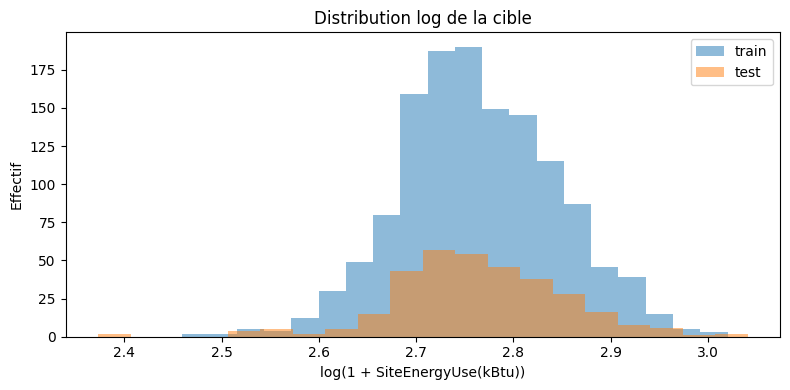

In [24]:
# Lecture des fichiers
train_std = pd.read_csv("../data/processed/split/train_std.csv")
test_std  = pd.read_csv("../data/processed/split/test_std.csv")

# Plot histogramme en log
plt.figure(figsize=(8,4))
plt.hist(np.log1p(train_std[target]), bins=20, alpha=0.5, label='train')
plt.hist(np.log1p(test_std[target]),  bins=20, alpha=0.5, label='test')
plt.xlabel("log(1 + SiteEnergyUse(kBtu))")
plt.ylabel("Effectif")
plt.legend()
plt.title("Distribution log de la cible")
plt.tight_layout()
plt.show()


### Split basé sur PrimaryPropertyType et HasPool

In [10]:
combo_col = 'CategoryCombo'
df[combo_col] = df['PrimaryPropertyType'].astype(str) + "_" + df['HasPool'].astype(str)

train_cat = pd.DataFrame()
test_cat = pd.DataFrame()
small_pool = []
small_nopool = []
grouped_summary = {"Other_1": [], "Other_0": []}
added_only_to_train = {"Other_1": [], "Other_0": []}

# Traitement principal par combo
for combo in df[combo_col].dropna().unique():
    mask = df[combo_col] == combo
    subset = df[mask]
    has_pool = subset['HasPool'].iloc[0]
    # Split normal si taille > 5
    if len(subset) > 5:
        X_sub = subset.drop(target, axis=1)
        y_sub = subset[target]
        X_train, X_test, y_train, y_test = train_test_split(
            X_sub, y_sub, test_size=0.2, random_state=42
        )
        train_cf = pd.concat([X_train, y_train], axis=1)
        test_cf = pd.concat([X_test, y_test], axis=1)
        train_cf[combo_col] = combo
        test_cf[combo_col] = combo
        train_cat = pd.concat([train_cat, train_cf], ignore_index=True)
        test_cat = pd.concat([test_cat, test_cf], ignore_index=True)
    # Sinon, stockage pour pooling
    else:
        if has_pool == 1:
            small_pool.append((combo, len(subset)))
        else:
            small_nopool.append((combo, len(subset)))

# Pooling pour petits groupes
df_small_pool = pd.concat([df[df[combo_col] == c] for c, n in small_pool], ignore_index=True) if small_pool else pd.DataFrame()
df_small_nopool = pd.concat([df[df[combo_col] == c] for c, n in small_nopool], ignore_index=True) if small_nopool else pd.DataFrame()

for pooled_df, pooled_list, has_pool, label in [
    (df_small_pool, small_pool, 1, "Other_1"),
    (df_small_nopool, small_nopool, 0, "Other_0")
]:
    if not pooled_df.empty:
        combos = [c for c, n in pooled_list]
        # Split du pooled si assez de data, sinon tout dans train
        if len(pooled_df) > 5:
            X_pool = pooled_df.drop(target, axis=1)
            y_pool = pooled_df[target]
            X_train, X_test, y_train, y_test = train_test_split(
                X_pool, y_pool, test_size=0.2, random_state=42
            )
            train_cf = pd.concat([X_train, y_train], axis=1)
            test_cf = pd.concat([X_test, y_test], axis=1)
            train_cf[combo_col] = label
            test_cf[combo_col] = label
            train_cat = pd.concat([train_cat, train_cf], ignore_index=True)
            test_cat = pd.concat([test_cat, test_cf], ignore_index=True)
            grouped_summary[label].append({"combos": combos, "total": len(pooled_df), "test_size": len(X_test)})
        else:
            pooled_df[combo_col] = label
            train_cat = pd.concat([train_cat, pooled_df], ignore_index=True)
            added_only_to_train[label].append({"combos": combos, "total": len(pooled_df)})

# Sauvegardes
train_cat.to_csv("../data/processed/split/train_cat.csv", index=False)
test_cat.to_csv("../data/processed/split/test_cat.csv", index=False)

# Affichage récapitulatif
print("\n#### RÉCAPITULATIF DES REGROUPEMENTS ####")
for pool_label in ["Other_1", "Other_0"]:
    for grp in grouped_summary[pool_label]:
        print(f"\nGroupé dans {pool_label} (=> split train/test) :")
        print(f"  - Combos : {', '.join(grp['combos'])}")
        print(f"  - Effectif total : {grp['total']} (test : {grp['test_size']})")
    for grp in added_only_to_train[pool_label]:
        print(f"\nAjouté uniquement au train dans {pool_label} (trop petit même regroupé) :")
        print(f"  - Combos : {', '.join(grp['combos'])}")
        print(f"  - Effectif total : {grp['total']}")



#### RÉCAPITULATIF DES REGROUPEMENTS ####

Ajouté uniquement au train dans Other_1 (trop petit même regroupé) :
  - Combos : Mixed Use Property_1
  - Effectif total : 1

Groupé dans Other_0 (=> split train/test) :
  - Combos : High-Rise Multifamily_0, Mid-Rise Multifamily_0, Office_0
  - Effectif total : 6 (test : 2)


#### Vérification

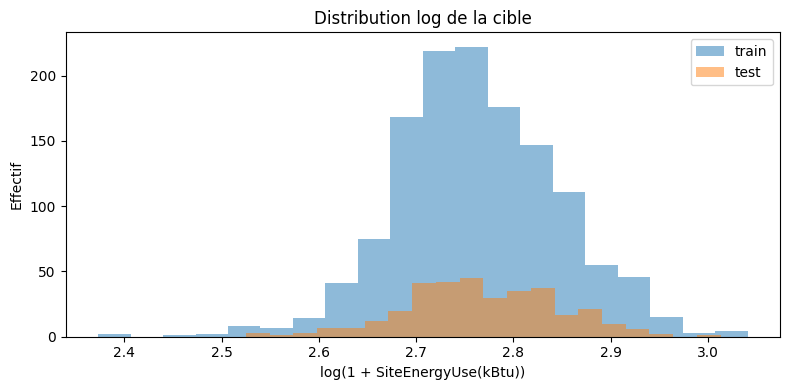

In [11]:
# Lecture des fichiers
train_cat = pd.read_csv("../data/processed/split/train_cat.csv")
test_cat  = pd.read_csv("../data/processed/split/test_cat.csv")

# Plot histogramme en log
plt.figure(figsize=(8,4))
plt.hist(np.log1p(train_cat[target]), bins=20, alpha=0.5, label='train')
plt.hist(np.log1p(test_cat[target]),  bins=20, alpha=0.5, label='test')
plt.xlabel("log(1 + SiteEnergyUse(kBtu))")
plt.ylabel("Effectif")
plt.legend()
plt.title("Distribution log de la cible")
plt.tight_layout()
plt.show()


## Définition des Features à utiliser

D'après notre précédente Analyse, nous allons utiliser les Features suivantes :

| Feature                        | Description                                                    |
|--------------------------------|----------------------------------------------------------------|
| **BuildingType**               | Type général de bâtiment (ex : résidentiel, commercial, etc.)  |
| **PrimaryPropertyType**        | Usage principal du bâtiment (bureau, école, etc.)              |
| **Neighborhood**               | Quartier où est situé le bâtiment                              |
| **YearBuilt**                  | Année de construction du bâtiment                              |
| **NumberofFloors**             | Nombre d’étages                                                |
| **PropertyGFABuilding(s)**     | Surface utile totale du bâtiment (m²)                          |
| **LargestPropertyUseType**     | Usage principal du bâtiment                                    |
| **LargestPropertyUseTypeGFA**  | Surface dédiée à l’usage principal (m²)                        |
| **SecondLargestPropertyUseType**      | Second usage le plus important du bâtiment         |
| **SecondLargestPropertyUseTypeGFA**   | Surface dédiée au second usage (m²)                |
| **ThirdLargestPropertyUseType** | Troisième usage majeur du bâtiment                             |
| **ThirdLargestPropertyUseTypeGFA**    | Surface dédiée au troisième usage (m²)             |
| **SiteEnergyUse(kBtu)**        | Consommation totale d’énergie du site (en kBtu)                |
| **UsageComplexity**            | Indicateur de complexité d’usage (multi-fonction, etc.)        |
| **HasNaturalGas**              | Présence de gaz naturel (1 = oui, 0 = non)                     |
| **HasSteam**                   | Présence de vapeur (1 = oui, 0 = non)                          |
| **DensityPerFloor**            | Densité (occupation ou usage) par étage                        |
| **IsLargeBuilding**            | Bâtiment de grande taille (1 = oui, 0 = non)                   |
| **IsDowntown**                 | Situé en centre-ville (1 = oui, 0 = non)                       |
| **HasPool**                    | Présence d’une piscine (1 = oui, 0 = non)                      |
| **ParkingRatio**               | Ratio nombre de parkings / surface ou nombre d’occupants       |
| **HasEnergyStarScore**         | Bâtiment avec score EnergyStar (1 = oui, 0 = non)              |


### Déclaration des Colonnes

In [25]:
# Liste des features utilisées
dataset = [
    "BuildingType",
    "PrimaryPropertyType",
    "Neighborhood",
    "YearBuilt",
    "NumberofFloors",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseType",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseType",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseType",
    "ThirdLargestPropertyUseTypeGFA",
    "UsageComplexity",
    "LogSiteEnergyUse",
    "HasNaturalGas",
    "HasSteam",
    "DensityPerFloor",
    "IsLargeBuilding",
    "IsDowntown",
    "HasPool",
    "ParkingRatio",
    "HasEnergyStarScore"
]

# Liste des features utilisées (hors target)
features = [
    "BuildingType",
    "PrimaryPropertyType",
    "Neighborhood",
    "YearBuilt",
    "NumberofFloors",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseType",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseType",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseType",
    "ThirdLargestPropertyUseTypeGFA",
    "UsageComplexity",
    "HasNaturalGas",
    "HasSteam",
    "DensityPerFloor",
    "IsLargeBuilding",
    "IsDowntown",
    "HasPool",
    "ParkingRatio",
    "HasEnergyStarScore"
]

# Colonnes catégorielles à encoder
cat_cols = [
    "BuildingType", "PrimaryPropertyType", "Neighborhood",
    "LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType"
]

# Colonnes à normaliser
cols_to_scale = [
    "BuildingType", "PrimaryPropertyType", "Neighborhood", "LargestPropertyUseType", 
    "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType", "YearBuilt",
    "NumberofFloors", "PropertyGFABuilding(s)", "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA", "ThirdLargestPropertyUseTypeGFA", "ParkingRatio", "UsageComplexity", "DensityPerFloor"
]

### Encoding des features catégorielles (target encoding)

Le target encoding consiste à remplacer les modalités d’une variable catégorielle par la moyenne de la variable **cible** (target) observée pour chaque catégorie.
Pour éviter le surapprentissage, notamment quand certaines catégories sont rares, nous appliquons **deux techniques complémentaires** :

**KFold encoding** : pour chaque observation du jeu d’entraînement, nous calculons la valeur encodée moins la cible de cette observation. Ainsi, nous évitons toute fuite d’information : la valeur utilisée pour encoder ne “voit” jamais la valeur à prédire de la ligne concernée.

**Smoothing (lissage)** : afin que les catégories très rares n’aient pas une valeur encodée trop extrême (peu fiable), nous calculons une moyenne pondérée entre la moyenne de la catégorie et la moyenne globale du jeu d’entraînement. C'est le paramètre **alpha** qui détermine l'équilibre entre ces deux moyennes (plus petit = préférence à la moyenen de catégorie, plus grand = préférence à la moyenne globale). En général, un alpha compris entre 10 et 50 fonctionne bien, nous prenons 30 comme valeur arbitraire de départ.

#### Encoding

In [13]:
def mean_target_encode_kfold_smooth(train_df, test_df, target, cols, n_splits=5, alpha=30):
    """
    Target encoding KFold + smoothing pour plusieurs colonnes.
    Les colonnes d'origine sont ECRASÉES par la version encodée.
    """
    train_enc = train_df.copy()
    test_enc  = test_df.copy()

    global_mean = train_df[target].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for col in cols:
        tr_values = np.zeros(train_df.shape[0])
        for train_idx, val_idx in kf.split(train_df):
            train_fold, val_fold = train_df.iloc[train_idx], train_df.iloc[val_idx]
            agg = train_fold.groupby(col)[target].agg(["mean", "count"])
            smooth = (agg["count"] * agg["mean"] + alpha * global_mean) / (agg["count"] + alpha)
            val_map = val_fold[col].map(smooth)
            tr_values[val_idx] = val_map.fillna(global_mean)
        # Test set : calcul sur tout le train
        agg = train_df.groupby(col)[target].agg(["mean", "count"])
        smooth = (agg["count"] * agg["mean"] + alpha * global_mean) / (agg["count"] + alpha)
        te_values = test_df[col].map(smooth).fillna(global_mean)

        train_enc[col] = tr_values
        test_enc[col] = te_values

    return train_enc, test_enc

# Encodage pour train_std / test_std
train_std = pd.read_csv("../data/processed/split/train_std.csv")
test_std  = pd.read_csv("../data/processed/split/test_std.csv")
train_std_te, test_std_te = mean_target_encode_kfold_smooth(train_std, test_std, target, cat_cols, n_splits=5, alpha=30)
train_std_te.to_csv("../data/processed/split/train_std_te.csv", index=False)
test_std_te.to_csv("../data/processed/split/test_std_te.csv", index=False)

# Encodage pour train_cat / test_cat
train_cat = pd.read_csv("../data/processed/split/train_cat.csv")
test_cat  = pd.read_csv("../data/processed/split/test_cat.csv")
train_cat_te, test_cat_te = mean_target_encode_kfold_smooth(train_cat, test_cat, target, cat_cols, n_splits=5, alpha=30)
train_cat_te.to_csv("../data/processed/split/train_cat_te.csv", index=False)
test_cat_te.to_csv("../data/processed/split/test_cat_te.csv", index=False)


In [14]:
# Chargement des données
train_std_te = pd.read_csv("../data/processed/split/train_std_te.csv")
test_std_te = pd.read_csv("../data/processed/split/test_std_te.csv")
train_cat_te = pd.read_csv("../data/processed/split/train_cat_te.csv")
test_cat_te = pd.read_csv("../data/processed/split/test_cat_te.csv")

# Contrôles - types et NaN
assert train_std_te[features].select_dtypes(include="object").shape[1] == 0, "train_std_te a des features non numériques !"
assert test_std_te[features].select_dtypes(include="object").shape[1] == 0, "test_std_te a des features non numériques !"
assert train_std_te[features].isnull().sum().sum() == 0, "train_std_te a des NaN dans features !"
assert test_std_te[features].isnull().sum().sum() == 0, "test_std_te a des NaN dans features !"

# Affichage train
display(train_std_te[features].head())
display(train_cat_te[features].head())

# Affichage test
display(test_std_te[features].head())
display(test_cat_te[features].head())

X = train_std_te[features]
y = train_std_te[target]
model = Ridge()
scores = cross_val_score(model, X, y, cv=3)
print("Mini cross-val Ridge, scores :", scores)


,BuildingType,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofFloors,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,...,ThirdLargestPropertyUseTypeGFA,UsageComplexity,HasNaturalGas,HasSteam,DensityPerFloor,IsLargeBuilding,IsDowntown,HasPool,ParkingRatio,HasEnergyStarScore
0,14.892586,14.276539,14.382267,1956,1,27000,14.276539,27000.0,14.919549,0.0,...,0.0,1,1,0,27000.0,0,0,0,0.0,1
1,14.823508,14.739047,14.979793,1948,1,64314,14.739047,65210.0,14.919549,0.0,...,0.0,1,1,0,64314.0,1,0,0,0.0,1
2,14.923842,14.164860,14.482887,1941,2,22324,14.175158,21000.0,14.919549,0.0,...,0.0,1,1,0,11162.0,0,0,0,0.0,1
3,14.923842,14.548674,15.075305,1925,4,39760,15.153916,39760.0,14.919549,0.0,...,0.0,1,1,1,9940.0,0,0,0,0.0,1
4,14.885722,14.801359,15.390448,1957,2,21600,14.801359,21600.0,14.919549,0.0,...,0.0,1,1,0,10800.0,0,1,0,0.0,1


,BuildingType,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofFloors,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,...,ThirdLargestPropertyUseTypeGFA,UsageComplexity,HasNaturalGas,HasSteam,DensityPerFloor,IsLargeBuilding,IsDowntown,HasPool,ParkingRatio,HasEnergyStarScore
0,14.867153,15.405957,15.294830,1959,4,38520,15.412541,38500.0,14.906705,0.0,...,0.0,1,1,0,9630.000000,0,0,0,0.000000,1
1,14.909374,15.454659,15.153420,1961,3,24930,15.462037,19000.0,14.906705,0.0,...,0.0,1,1,0,8310.000000,0,0,0,0.145823,1
2,14.904522,15.517619,14.828795,1930,3,20571,15.525910,20571.0,14.906705,0.0,...,0.0,1,0,0,6857.000000,0,0,0,0.000000,1
3,14.904522,15.517619,15.394284,1998,25,272015,15.525910,336640.0,14.906705,0.0,...,0.0,1,1,1,10880.600000,1,1,0,0.183570,1
4,14.888008,15.375389,15.361217,1973,19,272787,15.375389,332067.0,14.906705,0.0,...,0.0,1,1,1,14357.210526,1,1,0,0.178518,1


,BuildingType,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofFloors,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,...,ThirdLargestPropertyUseTypeGFA,UsageComplexity,HasNaturalGas,HasSteam,DensityPerFloor,IsLargeBuilding,IsDowntown,HasPool,ParkingRatio,HasEnergyStarScore
0,14.907797,14.131527,14.745368,1950,1,27553,14.142235,27553.0,14.919549,0.0,...,0.0,1,1,0,27553.000000,0,0,0,0.0,1
1,14.907797,14.298933,14.734386,1977,2,33344,14.318925,31360.0,14.619598,984.0,...,0.0,3,0,0,16672.000000,0,0,0,0.0,0
2,14.907797,14.581534,14.413257,1983,1,23143,15.165461,15609.0,14.612359,7534.0,...,0.0,2,1,0,23143.000000,0,0,0,0.0,1
3,14.907797,14.759779,15.419896,1940,3,83118,14.754027,45000.0,14.919549,0.0,...,0.0,1,1,0,27706.000000,1,1,0,0.0,1
4,14.907797,15.488765,15.053700,1928,6,35770,15.501550,35770.0,14.919549,0.0,...,0.0,1,1,0,5961.666667,0,0,0,0.0,1


,BuildingType,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofFloors,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,...,ThirdLargestPropertyUseTypeGFA,UsageComplexity,HasNaturalGas,HasSteam,DensityPerFloor,IsLargeBuilding,IsDowntown,HasPool,ParkingRatio,HasEnergyStarScore
0,14.888228,15.480036,15.371331,1967,4,44416,15.486712,52668.0,14.906705,0.0,...,0.0,1,1,0,11104.000000,0,1,0,0.000000,1
1,14.888228,15.480036,14.862919,1994,4,81871,15.486712,81871.0,14.906705,0.0,...,0.0,1,1,0,20467.750000,1,0,0,0.000000,1
2,14.888228,15.480036,15.371331,1926,11,83008,15.486712,81352.0,14.906705,0.0,...,0.0,1,1,0,7546.181818,1,1,0,0.000000,1
3,14.888228,15.480036,15.371331,1980,33,258352,15.486712,295511.0,15.601814,57600.0,...,0.0,2,1,1,7828.848485,1,1,0,0.182306,1
4,14.888228,15.480036,15.220141,1990,7,238097,15.486712,235788.0,15.601814,51537.0,...,0.0,2,1,0,34013.857143,1,0,0,0.158260,1


Mini cross-val Ridge, scores : [0.56758616 0.59894026 0.64728046]


## Normalisation

In [15]:
def normalise_dataset(train_df, test_df, cols):
    scaler = StandardScaler()
    train_copy = train_df.copy()
    test_copy = test_df.copy()
    # On fit sur le train, puis on transforme train & test sur les mêmes colonnes
    train_copy[cols] = scaler.fit_transform(train_copy[cols])
    test_copy[cols] = scaler.transform(test_copy[cols])
    return train_copy, test_copy

# Application aux deux jeux
train_std_te_norm, test_std_te_norm = normalise_dataset(train_std_te, test_std_te, cols_to_scale)
train_cat_te_norm, test_cat_te_norm = normalise_dataset(train_cat_te, test_cat_te, cols_to_scale)

# Sauvegarde des résultats normalisés
train_std_te_norm.to_csv("../data/processed/split/train_std_te_norm.csv", index=False)
test_std_te_norm.to_csv("../data/processed/split/test_std_te_norm.csv", index=False)
train_cat_te_norm.to_csv("../data/processed/split/train_cat_te_norm.csv", index=False)
test_cat_te_norm.to_csv("../data/processed/split/test_cat_te_norm.csv", index=False)


### Vérification

In [16]:
# Liste des colonnes à vérifier

def check_normalisation(df, cols, df_name="df"):
    print(f"\nVérification de la normalisation sur {df_name} :")
    stats = df[cols].agg(['mean', 'std']).T.round(3)
    print(stats)
    # Option : contrôle auto sur la tolérance
    tol = 1e-2  # tolérance relative
    print("Vérification terminée.\n")

# Sur chaque dataset normalisé
check_normalisation(train_std_te_norm, cols_to_scale, "train_std_te_norm")
check_normalisation(test_std_te_norm, cols_to_scale, "test_std_te_norm")
check_normalisation(train_cat_te_norm, cols_to_scale, "train_cat_te_norm")
check_normalisation(test_cat_te_norm, cols_to_scale, "test_cat_te_norm")



Vérification de la normalisation sur train_std_te_norm :
                                 mean  std
BuildingType                     -0.0  1.0
PrimaryPropertyType              -0.0  1.0
Neighborhood                     -0.0  1.0
LargestPropertyUseType           -0.0  1.0
SecondLargestPropertyUseType      0.0  1.0
ThirdLargestPropertyUseType      -0.0  1.0
YearBuilt                         0.0  1.0
NumberofFloors                   -0.0  1.0
PropertyGFABuilding(s)           -0.0  1.0
LargestPropertyUseTypeGFA        -0.0  1.0
SecondLargestPropertyUseTypeGFA  -0.0  1.0
ThirdLargestPropertyUseTypeGFA   -0.0  1.0
SiteEnergyUseWN(kBtu)            -0.0  1.0
ParkingRatio                      0.0  1.0
DensityPerFloor                  -0.0  1.0
Vérification terminée.


Vérification de la normalisation sur test_std_te_norm :
                                  mean    std
BuildingType                     0.052  1.153
PrimaryPropertyType             -0.046  1.033
Neighborhood                    -0.

Après normalisation, nous constatons que les jeux de tests ont des valeurs hors du range [0;1], c'est normal (on a fit sur train)

## Modélisation

Nous avons choisi 3 modélisations :
- **Régression Linéaire** (Ridge)
- **Forêt d'Arbres de Décision** (RandomForestRegressor)
- **Arbres Boostés** (GradientBoostingRegressor)

Nous nous attendons à avoir de meilleures performances sur le dernier.
Pour évaluer ces performances, nous allons utiliser les 3 métriques suivantes : **R2**, **MAE** et **RMSE**

| Score    | À quoi ça sert ?                | Comment lire le résultat ?           |
|----------|---------------------------------|--------------------------------------|
| R²       | Indique la part de la variation expliquée par le modèle | Plus c’est proche de 1, mieux c’est. 0 = aucune explication. |
| MAE      | Erreur moyenne “en unité réelle” entre vrai et prédit   | Plus c’est bas, mieux c’est. S’exprime dans la même unité que la cible. |
| RMSE     | Comme MAE mais “gonfle” les grosses erreurs             | Plus c’est bas, mieux c’est. Sensible aux grosses erreurs.       |


### Pipeline de traitement

Comme nous avons souhaité comparer 2 méthodes de split, pour simplifier le traitement et limiter les répétitions, nous mettons en place un pipeline

In [17]:
pipelines = [
    {
        'name': 'split standard',
        'train_file': '../data/processed/split/train_std_te_norm.csv',
        'test_file': '../data/processed/split/test_std_te_norm.csv'
    },
    {
        'name': 'split catégoriel',
        'train_file': '../data/processed/split/train_cat_te_norm.csv',
        'test_file': '../data/processed/split/test_cat_te_norm.csv'
    }
]

### Régression Linéaire

In [22]:
for pipe in pipelines:
    print(f"\n======= Pipeline : {pipe['name']} =======")
    # Chargement des données pour ce pipeline
    train = pd.read_csv(pipe['train_file'])
    test = pd.read_csv(pipe['test_file'])
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    # Modèle Ridge
    model = Ridge(random_state=42)
    scoring = {
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    }
    # Cross-validation sur le train (log(1+target))
    cv_results = cross_validate(
        model, X_train, y_train,
        scoring=scoring, cv=5, return_train_score=False
    )
    print("Moyenne des scores en CV sur le train (log(1+target)) :")
    print("  R2   :", cv_results['test_r2'].mean())
    print("  MAE  :", -cv_results['test_mae'].mean())
    print("  RMSE :", -cv_results['test_rmse'].mean())
   
    # Fit sur tout le train
    model.fit(X_train, y_train)
    
    # Prédictions sur le test (log(1+target))
    y_pred_test = model.predict(X_test)
    
    print("Scores finaux (test, log(1+target)) :")
    print("  R2   :", r2_score(y_test, y_pred_test))
    print("  MAE  :", mean_absolute_error(y_test, y_pred_test))
    print("  RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_test)))



======= Pipeline : split standard =======
Moyenne des scores en CV sur le train (log(1+target)) :
  R2   : 0.6279261303995607
  MAE  : 0.5925743836027983
  RMSE : 0.7854972511547856
Scores finaux (test, log(1+target)) :
  R2   : 0.6507529425962509
  MAE  : 0.6168726683013883
  RMSE : 0.8266575682711912

======= Pipeline : split catégoriel =======
Moyenne des scores en CV sur le train (log(1+target)) :
  R2   : 0.5100990176206549
  MAE  : 0.6349453515287344
  RMSE : 0.8482859331058906
Scores finaux (test, log(1+target)) :
  R2   : 0.6573845046172517
  MAE  : 0.5807826014524947
  RMSE : 0.7408346158345558


### Forêt d'Arbres de Décision

In [34]:
for pipe in pipelines:
    print(f"\n======= Pipeline : {pipe['name']} =======")
    # Chargement des données pour ce pipeline
    train = pd.read_csv(pipe['train_file'])
    test = pd.read_csv(pipe['test_file'])
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]

    # Modèle Random Forest
    model = RandomForestRegressor(
        n_estimators=100, 
        random_state=42,
        n_jobs=-1
    )

    scoring = {
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    }

    # Cross-validation sur le train (log(1+target))
    cv_results = cross_validate(
        model, X_train, y_train,
        scoring=scoring, cv=5, return_train_score=False,
        n_jobs=-1
    )
    print("Moyenne des scores en CV sur le train (log(1+target)) :")
    print("  R2   :", cv_results['test_r2'].mean())
    print("  MAE  :", -cv_results['test_mae'].mean())
    print("  RMSE :", -cv_results['test_rmse'].mean())

    # Fit sur tout le train
    model.fit(X_train, y_train)

    # Prédictions sur le test (log(1+target))
    y_pred_test = model.predict(X_test)
    print("Scores finaux (test, log(1+target)) :")
    print("  R2   :", r2_score(y_test, y_pred_test))
    print("  MAE  :", mean_absolute_error(y_test, y_pred_test))
    print("  RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_test)))



======= Pipeline : split standard =======
Moyenne des scores en CV sur le train (log(1+target)) :
  R2   : 0.7209203311932696
  MAE  : 0.5032161472199794
  RMSE : 0.6813058615563099
Scores finaux (test, log(1+target)) :
  R2   : 0.7138198795113364
  MAE  : 0.5285852617076939
  RMSE : 0.7483056071505321

======= Pipeline : split catégoriel =======
Moyenne des scores en CV sur le train (log(1+target)) :
  R2   : 0.5678980739336652
  MAE  : 0.6169161302139096
  RMSE : 0.8046118691991404
Scores finaux (test, log(1+target)) :
  R2   : 0.7157929950154701
  MAE  : 0.5179738157776961
  RMSE : 0.6747379780006356


### Arbres Boostés

In [35]:
for pipe in pipelines:
    print(f"\n======= Pipeline : {pipe['name']} =======")
    # Chargement des données
    train = pd.read_csv(pipe['train_file'])
    test = pd.read_csv(pipe['test_file'])
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]

    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    scoring = {
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    }

    # Cross-validation sur le train (log(1+target))
    cv_results = cross_validate(
        model, X_train, y_train,
        scoring=scoring, cv=5, return_train_score=False, n_jobs=-1
    )
    print("Moyenne des scores en CV sur le train (log(1+target)) :")
    print("  R2   :", cv_results['test_r2'].mean())
    print("  MAE  :", -cv_results['test_mae'].mean())
    print("  RMSE :", -cv_results['test_rmse'].mean())

    # Fit sur tout le train
    model.fit(X_train, y_train)

    # Prédiction finale sur le test (log(1+target))
    y_pred_test = model.predict(X_test)
    print("Scores finaux (test, log(1+target)) :")
    print("  R2   :", r2_score(y_test, y_pred_test))
    print("  MAE  :", mean_absolute_error(y_test, y_pred_test))
    print("  RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_test)))



======= Pipeline : split standard =======
Moyenne des scores en CV sur le train (log(1+target)) :
  R2   : 0.723320872056491
  MAE  : 0.502061594839035
  RMSE : 0.6784339940275196
Scores finaux (test, log(1+target)) :
  R2   : 0.7158725691273206
  MAE  : 0.5299992361902065
  RMSE : 0.7456170845098876

======= Pipeline : split catégoriel =======
Moyenne des scores en CV sur le train (log(1+target)) :
  R2   : 0.5725027005838428
  MAE  : 0.6205564806597356
  RMSE : 0.802813841316661
Scores finaux (test, log(1+target)) :
  R2   : 0.7028773391486178
  MAE  : 0.5332390163018362
  RMSE : 0.6898992204271014


### Récapitulatif des scores

| Pipeline          | Modèle           | CV train R² | CV train MAE | CV train RMSE | Test R² | Test MAE | Test RMSE |
|-------------------|------------------|:-----------:|:------------:|:-------------:|:-------:|:--------:|:---------:|
| Split standard    | Linéaire         | 0.628       | 0.593        | 0.785         | 0.651   | 0.617    | 0.827     |
| Split standard    | Forêt aléatoire  | 0.721       | 0.503        | 0.681         | 0.714   | 0.529    | 0.748     |
| Split standard    | Boosting         | 0.723       | 0.502        | 0.678         | 0.716   | 0.530    | 0.746     |
| Split catégoriel  | Linéaire         | 0.510       | 0.635        | 0.848         | 0.657   | 0.581    | 0.741     |
| Split catégoriel  | Forêt aléatoire  | 0.568       | 0.617        | 0.805         | 0.716   | 0.518    | 0.675     |
| Split catégoriel  | Boosting         | 0.573       | 0.621        | 0.803         | 0.703   | 0.533    | 0.690     |

### Premières conclusions :

Avec le Split "Catégoriel", les scores **test** sont meilleurs que les scores **train** en **CV**.
Celà suggère que le **split ciblé** induit une forme de leakage, car le **test** surperforme le **train**

Seul le jeu de données avec **split standard** sera utilisé pour la suite.

| Modèle           | Test R² | Test MAE | Test RMSE |
|------------------|:-------:|:--------:|:---------:|
| Linéaire         | 0.651   | 0.617    | 0.827     |
| Forêt aléatoire  | 0.714   | 0.529    | 0.748     |
| Boosting         | 0.716   | 0.530    | 0.746     |

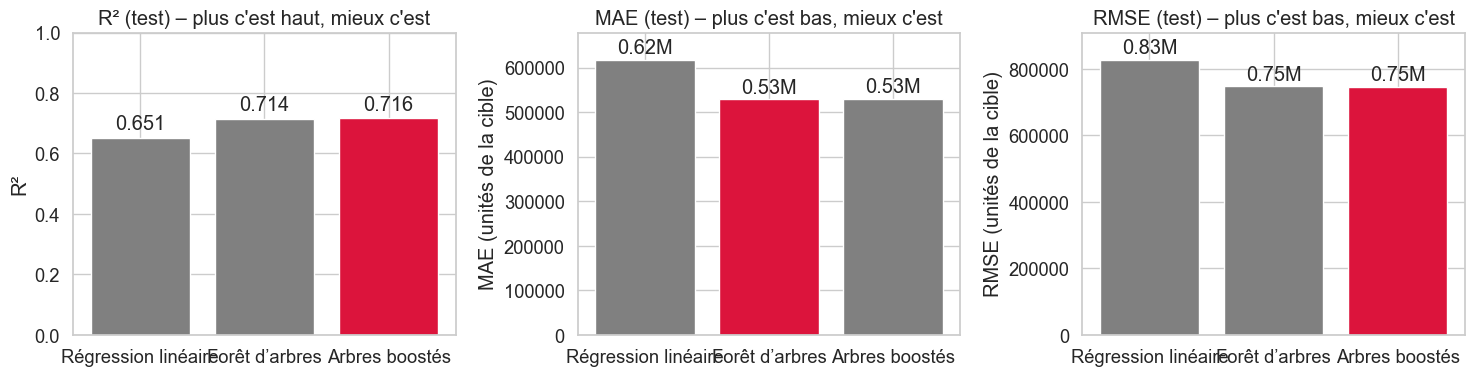

In [38]:
data = [
    ['Régression linéaire', 0.651, 0.617 * 1e6, 0.827 * 1e6],
    ['Forêt d’arbres',      0.714, 0.529 * 1e6, 0.748 * 1e6],
    ['Arbres boostés',      0.716, 0.530 * 1e6, 0.746 * 1e6]
]
df_res = pd.DataFrame(data, columns=['Modèle', 'R2', 'MAE', 'RMSE'])

# Highlight setup
best_r2 = df_res['R2'].idxmax()
highlight_colors = ['grey'] * len(df_res)
highlight_colors[best_r2] = 'crimson'

sns.set(style="whitegrid", font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# R²
axes[0].bar(df_res['Modèle'], df_res['R2'], color=highlight_colors)
axes[0].set_title("R² (test) – plus c'est haut, mieux c'est")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("R²")
for idx, val in enumerate(df_res['R2']):
    axes[0].text(idx, val + 0.015, f"{val:.3f}", ha='center', va='bottom')

# MAE
best_mae = df_res['MAE'].idxmin()
highlight_colors_mae = ['grey'] * len(df_res)
highlight_colors_mae[best_mae] = 'crimson'
axes[1].bar(df_res['Modèle'], df_res['MAE'], color=highlight_colors_mae)
axes[1].set_title("MAE (test) – plus c'est bas, mieux c'est")
axes[1].set_ylabel("MAE (unités de la cible)")
axes[1].set_ylim(0, 1.1 * df_res['MAE'].max())
for idx, val in enumerate(df_res['MAE']):
    axes[1].text(idx, val * 1.01, f"{val/1e6:.2f}M", ha='center', va='bottom')

# RMSE
best_rmse = df_res['RMSE'].idxmin()
highlight_colors_rmse = ['grey'] * len(df_res)
highlight_colors_rmse[best_rmse] = 'crimson'
axes[2].bar(df_res['Modèle'], df_res['RMSE'], color=highlight_colors_rmse)
axes[2].set_title("RMSE (test) – plus c'est bas, mieux c'est")
axes[2].set_ylabel("RMSE (unités de la cible)")
axes[2].set_ylim(0, 1.1 * df_res['RMSE'].max())
for idx, val in enumerate(df_res['RMSE']):
    axes[2].text(idx, val * 1.01, f"{val/1e6:.2f}M", ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Conclusion

Le modèle le plus performant est celui des arbres boostés comme attendu, mais la différence semble plutôt faible par rapport à la forêt d'Arbres.

Ces scores sont calculés sur le log(1+Target), Il conviendra de les calculer sur l'échelle des valeurs brutes pour avoir un scor plus fidèle et plus parlant.

In [52]:
# Chargement des données du split standard
train = pd.read_csv("../data/processed/split/train_std_te_norm.csv")  # adapte le nom de ton fichier
test = pd.read_csv("../data/processed/split/test_std_te_norm.csv")
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Fit sur tout le train (sur log(1+target) si c'était la transformation)
model.fit(X_train, y_train)

# Prédiction finale sur le test
y_pred_test = model.predict(X_test)

# Si tu avais transformé la cible, inverse la transformation :
# (sinon, retire la ligne ci-dessous si ce n'est PAS du log(1+target))
y_pred_test_orig = np.expm1(y_pred_test)
y_test_orig = np.expm1(y_test)

print("\nScores finaux (test, échelle d'origine) :")
print("  MAE  :", mean_absolute_error(y_test_orig, y_pred_test_orig))
print("  RMSE :", np.sqrt(mean_squared_error(y_test_orig, y_pred_test_orig)))


Scores finaux (test, échelle d'origine) :
  MAE  : 5119910.841778692
  RMSE : 24127976.615178816


#### Rappel des stats de la cible

Concernant les scores, le **R2** est assez explicite, mais les deux autres beaucoup moins, car il faut avoir en tête l'ordre de grandeur des valeurs de la cible pour se faire une idée.

In [42]:
print(df_cleaned['SiteEnergyUse(kBtu)'].describe())

count    1.656000e+03
mean     8.044542e+06
std      2.164895e+07
min      1.680890e+04
25%      1.253390e+06
50%      2.615611e+06
75%      7.052509e+06
max      4.483853e+08
Name: SiteEnergyUse(kBtu), dtype: float64


Deux autres métriques peut-être plus parlantes seraient le **MAE relatif** (MAE%),  qui permet de voir l'erreur absolue exprimée en pourcentage de la valeur de la cible, et le **MAE médiant** (MedAE%) qui s'en rapproche, mais basé sur les valeurs médianes plutôt que la moyenne, donc plus robuste aux outliers :

In [51]:
# Métriques pour le Test avec Arbres boostés (attention, en mémoire ce sont les résultats avec le split catégoriel)

# Calcul du MAE absolu
mae = np.mean(np.abs(y_test_orig - y_pred_test_orig))

# Calcul RMSE : 
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_test_orig))

# Calcul MAE% (par rapport à la moyenne de la cible)
mae_pct = (mae / y_test_orig.mean()) * 100

# Calcul de l’erreur absolue médiane
medae = median_absolute_error(y_test_orig, y_pred_test_orig)

# MedAE% en % de la moyenne de la cible
medae_pct = (medae / y_test_orig.mean()) * 100

print(f"MAE : {mae:.0f}")
print(f"RMSE : {rmse:.0f}")
print(f"Moyenne de la cible : {y_test_orig.mean():.0f}")
print(f"MAE% (en % de la moyenne) : {mae_pct:.2f} %")
print(f"MedAE : {medae:.0f}")
print(f"MedAE% : {medae_pct:.2f} %")

# Rappel de R2
print("  R2   :", r2_score(y_test_orig, y_pred_test_orig))

MAE : 5119911
RMSE : 24127977
Moyenne de la cible : 9568218
MAE% (en % de la moyenne) : 53.51 %
MedAE : 937625
MedAE% : 9.80 %
  R2   : 0.4429542095327631


Pour la majorité des bâtiments, l'erreur de prédiction est limitée à **9,8 %** (**MedAE%**).

L'erreur moyenne (**MAE%**) s’élève à **53 %** de la moyenne, pénalisée par les cas de très forte consommation difficiles à anticiper.

Le modèle explique **72 %** de la variabilité des consommations (**R²**).

L'erreur Moyenne (**MAE**) est de 5,1M Btu, pour des valeurs comprises entre 16k et 448M Btu. Le modèle semble majoritairement faire de bonnes prédictions, mais faire plus d'erreur sur les bâtiments à très forte consommation. C'est ce que tend à confirmer le **RMSE** de 24,1M Btu, qui par son fonctionnement donne plus de poids au plus grosses erreurs.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
from category_encoders import TargetEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,median_absolute_error

nonresidential_building_consumption = pd.read_csv("../data/processed/building_consumption_non-residential_cleaned.csv")

# Suppression des lignes où la conso est nulle
df_cleaned = nonresidential_building_consumption.dropna(subset=["SiteEnergyUse(kBtu)"])
df_cleaned = df_cleaned[df_cleaned['SiteEnergyUse(kBtu)'] != 0].reset_index(drop=True)

# Suppression du bâtiment trop grand identifié dans l'analyse exploratoire (campus)
df_cleaned = df_cleaned[df_cleaned['OSEBuildingID'] != 49967]

#Remplacement des NaN des PropertyUseGFA par des 0
cols_gfa = ['LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA']
for col in cols_gfa:
    df_cleaned[col] = df_cleaned[col].fillna(0)
    df_cleaned[col] = df_cleaned[col].fillna(0)

# CODE FEATURE ENGINEERING

df = df_cleaned.copy()

# 1 ParkingRatio : ratio parking / surface totale
df['ParkingRatio'] = df.apply(
    lambda row: row['PropertyGFAParking'] / row['PropertyGFATotal']
    if row['PropertyGFATotal'] and pd.notnull(row['PropertyGFAParking']) else 0,
    axis=1
)

# 2 UsageComplexity : nombre d'usages différents
df['UsageComplexity'] = df['ListOfAllPropertyUseTypes'].apply(
    lambda s: len(s.split(', ')) if pd.notnull(s) else 0
)

# 3 HasNaturalGas : Gaz ou pas
df['HasNaturalGas'] = df['NaturalGas(therms)'].apply(lambda x: 1 if pd.notnull(x) and x > 0 else 0)

# 4 HasSteam : Vapeur ou pas
df['HasSteam']      = df['SteamUse(kBtu)'].apply(lambda x: 1 if pd.notnull(x) and x > 0 else 0)

# 5 HasEnergyStarScore : présence d'un score ENERGY STAR
df['HasEnergyStarScore'] = df['ENERGYSTARScore'].apply(lambda x: 1 if pd.notnull(x) else 0)

# 6 DensityPerFloor : densité d'espace par étage
df['DensityPerFloor'] = df.apply(
    lambda row: (
        row['PropertyGFABuilding(s)']
        if pd.notnull(row['PropertyGFABuilding(s)']) and row['NumberofFloors'] == 0
        else (
            row['PropertyGFABuilding(s)'] / row['NumberofFloors']
            if row['NumberofFloors'] and pd.notnull(row['PropertyGFABuilding(s)']) else None
        )
    ),
    axis=1
)

# 7 IsLargeBuilding : indicateur de grande taille (> median PropertyGFATotal)
median_gfa = df['PropertyGFATotal'].median()
df['IsLargeBuilding'] = df['PropertyGFATotal'].apply(lambda x: 1 if x > median_gfa else 0)

# 8 IsDowntown : localisation centre-ville (Neighborhood == 'DOWNTOWN')
df['IsDowntown'] = df['Neighborhood'].apply(lambda x: 1 if x == 'DOWNTOWN' else 0)

# 9 HasPool présence de "pool" ou "swimming" dans ListOfAllPropertyUseTypes
df['HasPool'] = df['ListOfAllPropertyUseTypes'].str.contains('pool|swimming', case=False, na=False).astype(int)

#10 Log de SiteEnergyUse
df['LogSiteEnergyUse'] = np.log1p(df['SiteEnergyUse(kBtu)'])

target = 'LogSiteEnergyUse'

# Binning pour stratification
X = df.drop(target, axis=1)
y = df[target]
y_binned = pd.qcut(y, q=20, duplicates="drop", labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_binned
)

# Fusion train/test
train_std = pd.concat([X_train, y_train], axis=1)
test_std = pd.concat([X_test, y_test], axis=1)

# Sauvegarde fichiers propres
train_std.to_csv("../data/processed/split/train_std.csv", index=False)
test_std.to_csv("../data/processed/split/test_std.csv", index=False)

# Liste des features utilisées
dataset = [
    "BuildingType",
    "PrimaryPropertyType",
    "Neighborhood",
    "YearBuilt",
    "NumberofFloors",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseType",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseType",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseType",
    "ThirdLargestPropertyUseTypeGFA",
    "UsageComplexity",
    "LogSiteEnergyUse",
    "HasNaturalGas",
    "HasSteam",
    "DensityPerFloor",
    "IsLargeBuilding",
    "IsDowntown",
    "HasPool",
    "ParkingRatio",
    "HasEnergyStarScore"
]

# Liste des features utilisées (hors target)
features = [
    "BuildingType",
    "PrimaryPropertyType",
    "Neighborhood",
    "YearBuilt",
    "NumberofFloors",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseType",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseType",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseType",
    "ThirdLargestPropertyUseTypeGFA",
    "UsageComplexity",
    "HasNaturalGas",
    "HasSteam",
    "DensityPerFloor",
    "IsLargeBuilding",
    "IsDowntown",
    "HasPool",
    "ParkingRatio",
    "HasEnergyStarScore"
]

# Colonnes catégorielles à encoder
cat_cols = [
    "BuildingType", "PrimaryPropertyType", "Neighborhood",
    "LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType"
]

# Colonnes à normaliser
cols_to_scale = [
    "BuildingType", "PrimaryPropertyType", "Neighborhood", "LargestPropertyUseType", 
    "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType", "YearBuilt",
    "NumberofFloors", "PropertyGFABuilding(s)", "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA", "ThirdLargestPropertyUseTypeGFA", "ParkingRatio", "UsageComplexity", "DensityPerFloor"
]


In [2]:

# Séquencement : TargetEncoder (cat_cols) → StandardScaler sur cols_to_scale → Regression

# Pipeline TargetEncoder (sur cat_cols)
pre_encoder = Pipeline([
    ('targetenc', TargetEncoder(cols=cat_cols))
])

# StandardScaler uniquement sur cols_to_scale, via ColumnTransformer natif
scaler = ColumnTransformer([
    ('scaler', StandardScaler(), cols_to_scale)
], remainder='passthrough')

pipe = Pipeline([
    ('encoder', pre_encoder),   # encode cat_cols --> tout devient numérique
    ('scaler', scaler),         # scale cols_to_scale, le reste inchangé
    ('reg', GradientBoostingRegressor(random_state=42))
])

# Définition des colonnes à utiliser en entrée
X_train_fit = train_std[features]
X_test_fit = test_std[features]

# Validation croisée appliquée à tous les traitements
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Paramètres pour le Grid Search (pris les standards de la doc et rafiné manuellement pour trouver le meilleur
param_grid = {
    'reg__n_estimators': [100, 200],
    'reg__max_depth': [3, 5],
    'reg__learning_rate': [0.07, 1]
}

# GridSearch avec CV appliqué sur le pipe
search = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)
search.fit(X_train_fit, y_train)

# Affichage des meilleurs paramètres
print("\nMeilleurs hyperparamètres trouvés :")
best_params = search.best_params_

# Zoli tableau
display(
    pd.DataFrame([best_params])
      .style
      .hide(axis='index')
      .set_properties(**{'text-align': 'center'})
      .format({'reg__learning_rate': '{:.2f}'})
)

# Scores sur la CV
cv_results = cross_validate(
    search.best_estimator_,
    X_train_fit, y_train,
    cv=cv,
    scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
    return_estimator=True
)

# Calcul des scores avec les valeurs brutes de consommation (pas LOG)
y_true_orig = np.expm1(y_test)
y_pred_test = search.best_estimator_.predict(X_test_fit)
y_pred_orig = np.expm1(y_pred_test)
mae_Mkbtu = mean_absolute_error(y_true_orig, y_pred_orig) / 1_000_000
rmse_Mkbtu = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig)) / 1_000_000

# On fait un DF pour pouvoir personnaliser l'affichage
scores = {
    "Score": ["R2 (test, log)", "MAE (test, log)", "RMSE (test, log)", "MAE (test, M.kBtu)", "RMSE (test, M.kBtu)"],
    "Valeur": [
        r2_score(y_test, y_pred_test),
        mean_absolute_error(y_test, y_pred_test),
        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        mae_Mkbtu,
        rmse_Mkbtu
    ]
}
scores_df = pd.DataFrame(scores)

# Zoli tableau
styled_scores = (scores_df
    .style
    .hide(axis='index')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])
)
display(styled_scores)

# Feature importance par fold

# On fait une boucle pour tout mettre dans un DF
all_importances = []
for estimator in cv_results['estimator']:
    reg = estimator.named_steps['reg']
    importance = pd.Series(reg.feature_importances_, index=features)
    all_importances.append(importance)

# On transpose le tableau pour avoir les features en lignes
importances_df = pd.DataFrame(all_importances).T
# On appelle les colonnes Fold_x pour simplifier le traitement
importances_df.columns = [f'fold_{i+1}' for i in range(importances_df.shape[1])]
# On traite chacune de ces colonnes (qui commencent donc par Fold_)
fold_cols = [col for col in importances_df.columns if col.startswith('fold_')]
# On groupe et on met en pourcentagre pour la lisibilité
importances_df['Moyenne (%)'] = 100 * importances_df[fold_cols].mean(axis=1) / importances_df[fold_cols].mean(axis=1).sum()
# On renomme les colonnes maintenant qu'on a fini
importances_df = importances_df.reset_index().rename(columns={"index": "Feature"})
# On range en décroissant (feature + importante en premier
importances_df = importances_df.sort_values('Moyenne (%)', ascending=False)

# Zoli tableau avec des couleurs à la heatmap
styled = (
    importances_df[['Feature', 'Moyenne (%)']]
    .style
    .hide(axis='index')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
    .background_gradient(subset=['Moyenne (%)'], cmap='Spectral_r')
    .format({'Moyenne (%)': '{:.2f}'})
)
display(styled)


Fitting 5 folds for each of 8 candidates, totalling 40 fits

Meilleurs hyperparamètres trouvés :


reg__learning_rate,reg__max_depth,reg__n_estimators
0.07,3,200


Score,Valeur
"R2 (test, log)",0.725537
"MAE (test, log)",0.519985
"RMSE (test, log)",0.732827
"MAE (test, M.kBtu)",4.950456
"RMSE (test, M.kBtu)",24.875843


Feature,Moyenne (%)
SecondLargestPropertyUseType,52.07
SecondLargestPropertyUseTypeGFA,16.32
YearBuilt,10.24
PrimaryPropertyType,8.80
LargestPropertyUseType,2.54
DensityPerFloor,2.19
HasSteam,1.53
ThirdLargestPropertyUseType,1.33
NumberofFloors,1.05
BuildingType,0.58


[CV] END reg__learning_rate=0.07, reg__max_depth=3, reg__n_estimators=100; total time=   0.6s
[CV] END reg__learning_rate=0.07, reg__max_depth=5, reg__n_estimators=100; total time=   0.9s
[CV] END reg__learning_rate=0.07, reg__max_depth=5, reg__n_estimators=200; total time=   1.8s
[CV] END reg__learning_rate=1, reg__max_depth=3, reg__n_estimators=200; total time=   1.2s
[CV] END reg__learning_rate=0.07, reg__max_depth=3, reg__n_estimators=200; total time=   1.1s
[CV] END reg__learning_rate=0.07, reg__max_depth=5, reg__n_estimators=100; total time=   0.9s
[CV] END reg__learning_rate=1, reg__max_depth=3, reg__n_estimators=100; total time=   0.7s
[CV] END reg__learning_rate=1, reg__max_depth=3, reg__n_estimators=200; total time=   1.3s
[CV] END reg__learning_rate=1, reg__max_depth=5, reg__n_estimators=100; total time=   0.9s
[CV] END reg__learning_rate=0.07, reg__max_depth=3, reg__n_estimators=200; total time=   1.1s
[CV] END reg__learning_rate=0.07, reg__max_depth=5, reg__n_estimators=20